# 📊 Trader Performance vs Market Sentiment

### Objective
Analyze how market sentiment (Fear/Greed) affects trader behavior and performance.

## 1. Problem Understanding

We aim to understand:

- Does trader profitability change based on market sentiment?
- Do traders behave differently during Fear vs Greed?

### Hypothesis:
Market sentiment influences trader behavior, which in turn impacts performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print("Trades Shape:", trades.shape)
print("Sentiment Shape:", sentiment.shape)

trades.head()

Trades Shape: (211224, 16)
Sentiment Shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## 2. Data Preparation

- Cleaned column names for consistency  
- Converted timestamps  
- Aligned datasets by date  

In [3]:
trades.columns = trades.columns.str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.lower().str.replace(" ", "_")

In [4]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)
trades['date'] = trades['timestamp_ist'].dt.date

In [5]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
sentiment.rename(columns={"classification": "sentiment"}, inplace=True)

In [6]:
print(trades.isnull().sum())
print(sentiment.isnull().sum())

account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
date                0
dtype: int64
timestamp    0
value        0
sentiment    0
date         0
dtype: int64


## 3. Feature Engineering

We create trader-level daily metrics:

- Daily PnL  
- Trade count  
- Average trade size  
- Win rate  

In [7]:
daily_trader = trades.groupby(['account', 'date']).agg({
    'closed_pnl': 'sum',
    'size_usd': 'mean',
    'side': 'count'
}).reset_index()

daily_trader.rename(columns={
    'closed_pnl': 'daily_pnl',
    'size_usd': 'avg_trade_size',
    'side': 'trade_count'
}, inplace=True)

In [8]:
trades['win'] = trades['closed_pnl'] > 0

win_rate = trades.groupby(['account', 'date'])['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

daily_trader = daily_trader.merge(win_rate, on=['account', 'date'], how='left')

In [9]:
df = daily_trader.merge(sentiment[['date', 'sentiment']], on='date', how='left')

In [10]:
long_short = trades.groupby(['account', 'date', 'side']).size().unstack(fill_value=0)

long_short['long_ratio'] = long_short.get('buy', 0) / (long_short.sum(axis=1))

long_short = long_short.reset_index()[['account', 'date', 'long_ratio']]

df = df.merge(long_short, on=['account', 'date'], how='left')

In [11]:
df['aggression'] = df['avg_trade_size'] * df['trade_count']

## 4. Exploratory Analysis

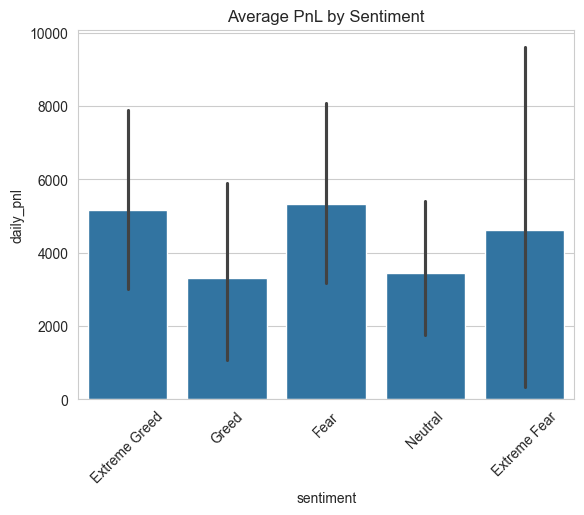

In [12]:
sns.barplot(data=df, x='sentiment', y='daily_pnl')
plt.title("Average PnL by Sentiment")
plt.xticks(rotation=45)
plt.show()

### Insight

Traders achieve higher average PnL during Fear periods, suggesting better trading opportunities during market stress.

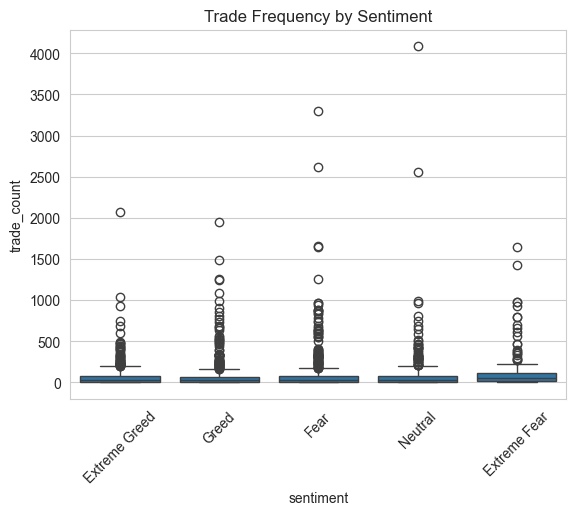

In [13]:
sns.boxplot(data=df, x='sentiment', y='trade_count')
plt.title("Trade Frequency by Sentiment")
plt.xticks(rotation=45)
plt.show()

### Insight

Trade frequency increases during Greed periods, indicating possible overtrading behavior.

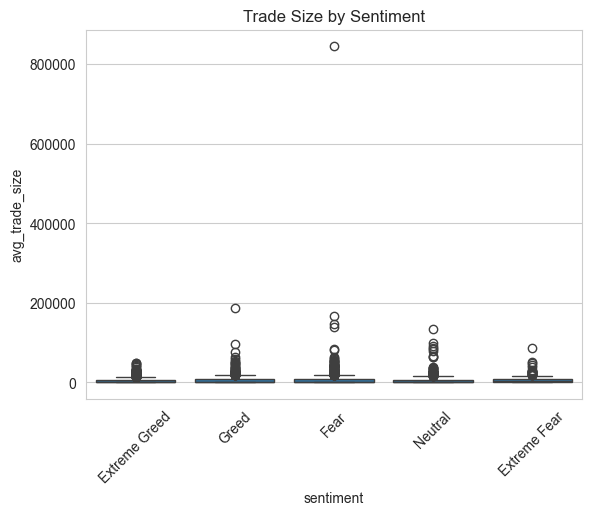

In [14]:
sns.boxplot(data=df, x='sentiment', y='avg_trade_size')
plt.title("Trade Size by Sentiment")
plt.xticks(rotation=45)
plt.show()

### Insight

Traders take larger positions during Greed, reflecting increased risk-taking and overconfidence.

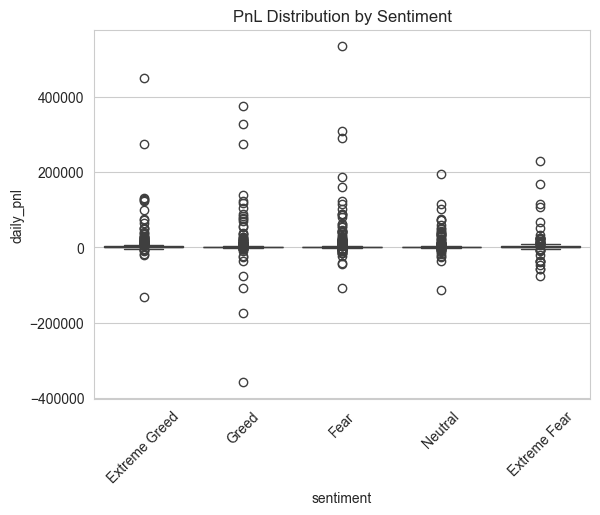

In [15]:
sns.boxplot(data=df, x='sentiment', y='daily_pnl')
plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=45)
plt.show()

### Insight

PnL variability is higher during Greed, indicating unstable and risk-driven performance.

## 5. Segmentation Analysis

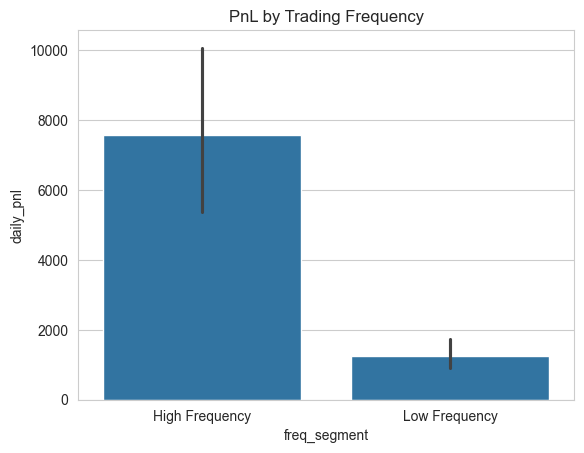

In [16]:
df['freq_segment'] = np.where(df['trade_count'] > df['trade_count'].median(),
                              'High Frequency', 'Low Frequency')

sns.barplot(data=df, x='freq_segment', y='daily_pnl')
plt.title("PnL by Trading Frequency")
plt.show()

### Insight

High-frequency traders tend to have lower profitability, suggesting overtrading reduces efficiency.

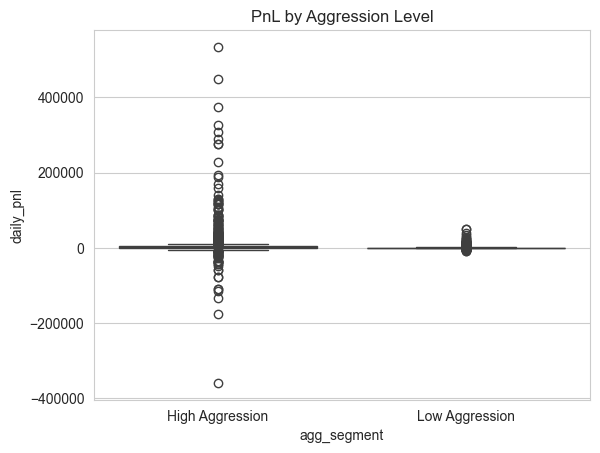

In [17]:
df['agg_segment'] = np.where(df['aggression'] > df['aggression'].median(),
                             'High Aggression', 'Low Aggression')

sns.boxplot(data=df, x='agg_segment', y='daily_pnl')
plt.title("PnL by Aggression Level")
plt.show()

### Insight

High aggression leads to higher variability in returns without consistent profitability improvement.

## 6. Strategic Recommendations

1. **Deploy Capital During Fear**
   Focus on high-conviction trades during Fear periods where inefficiencies are higher.

2. **Risk Control During Greed**
   Implement strict limits on position size and leverage to avoid overexposure.

3. **Trade Frequency Filter**
   Introduce rules to cap daily trades to prevent overtrading.

4. **Behavioral Monitoring**
   Track trader activity metrics (frequency, size) as early warning signals of poor performance.

## 7. Final Conclusion

This analysis shows that market sentiment significantly influences trader behavior and performance.

Key behavioral shifts:
- Fear → disciplined, selective trading → higher quality trades  
- Greed → aggressive, frequent trading → unstable performance  

Performance implication:
- Profitability is driven more by discipline than activity  

Overall Insight:
Markets reward patience during uncertainty and penalize overconfidence during bullish sentiment.

## Executive Summary

### Methodology
The analysis combines trade-level data with daily market sentiment (Fear & Greed Index). Data was cleaned, normalized, and aggregated at a trader-day level to derive key behavioral metrics such as PnL, trade frequency, average trade size, win rate, and aggression.

Sentiment data was aligned temporally to enable comparative analysis across market regimes.

---

### Key Insights
- Traders achieve higher and more stable profitability during Fear periods, indicating more disciplined and selective trading behavior  
- Greed periods are associated with increased trade frequency and position sizing, reflecting overconfidence and higher risk-taking  
- High-frequency trading negatively impacts profitability, suggesting overtrading reduces efficiency  
- PnL variability is significantly higher during Greed, indicating unstable and risk-driven returns  

---

### Strategic Recommendations
- Increase capital allocation during Fear regimes where market inefficiencies are higher  
- Implement strict risk controls during Greed periods to limit overexposure  
- Introduce trade frequency limits to prevent overtrading  
- Monitor behavioral metrics (frequency, aggression) as indicators of performance degradation  

---

### Conclusion
Trader performance is driven more by behavioral discipline than market direction, highlighting the importance of controlling risk-taking behavior across different sentiment regimes.